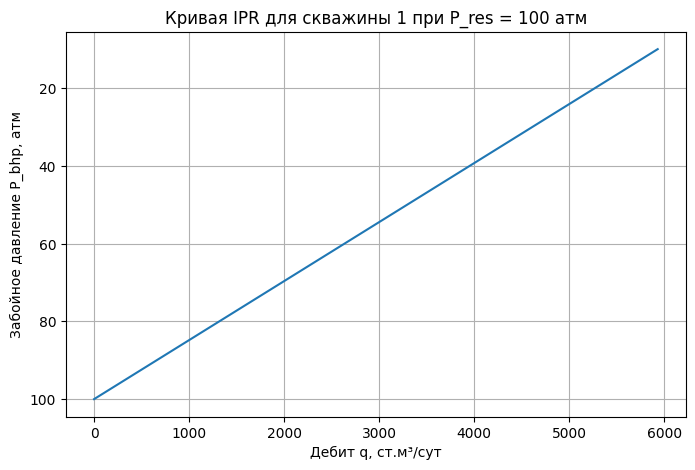

In [1]:
import sys
sys.path.append('.')
import matplotlib.pyplot as plt
import numpy as np
from src.fluid import Fluid
from src.reservoir import Reservoir, ResProps
from src.well import Well

# --- Данные студента (введены вручную) ---
xa = 0.3745
xy = 0.9507
rho_c = 0.6799
M_CH4 = 0.01604
M_N2 = 0.02801
M_CO2 = 0.04401
yCH4 = 1 - xa - xy
M = yCH4 * M_CH4 + xa * M_N2 + xy * M_CO2
T_res = 310.0

# --- 1. Тестирование IPR ---
# Параметры скважины
k, h, re, rw = 50.0, 25.0, 500.0, 0.1
fluid = Fluid(M, rho_c, xa, xy, T_res)
well = Well(fluid, k, h, re, rw)

# Построение кривой IPR
P_res = 100.0
P_bhp_range = np.linspace(10, 100, 50)
q_ipr = [well.ipr(P_res, pb) for pb in P_bhp_range]

plt.figure(figsize=(8,5))
plt.plot(q_ipr, P_bhp_range)
plt.xlabel('Дебит q, ст.м³/сут')
plt.ylabel('Забойное давление P_bhp, атм')
plt.title('Кривая IPR для скважины 1 при P_res = 100 атм')
plt.gca().invert_yaxis()
plt.grid(True)
plt.show()